# Spatial Analysis 

In [2]:
# Imports
import geopandas as gpd
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

In [3]:
# Load the data
# Load the quartiere polygons
BASE_DIR = Path().resolve().parent
quartiere_file_path = BASE_DIR / "data/raw/Zurich_quarters.gpkg"
quartiere_gdf = gpd.read_file(quartiere_file_path)

# Load the lakes
lakes_file_path = BASE_DIR / "data/processed/zurichsee.gpkg"
lakes_gdf = gpd.read_file(lakes_file_path)
lakes_gdf = lakes_gdf.to_crs(epsg=2056)

# Load the cleaned reports
reports_file_path = BASE_DIR / "data/processed/reports_cleaned.csv"
reports_df = pd.read_csv(reports_file_path)
reports_gdf = gpd.GeoDataFrame(
    reports_df, geometry=gpd.points_from_xy(reports_df.e, reports_df.n, crs="EPSG:2056")
)

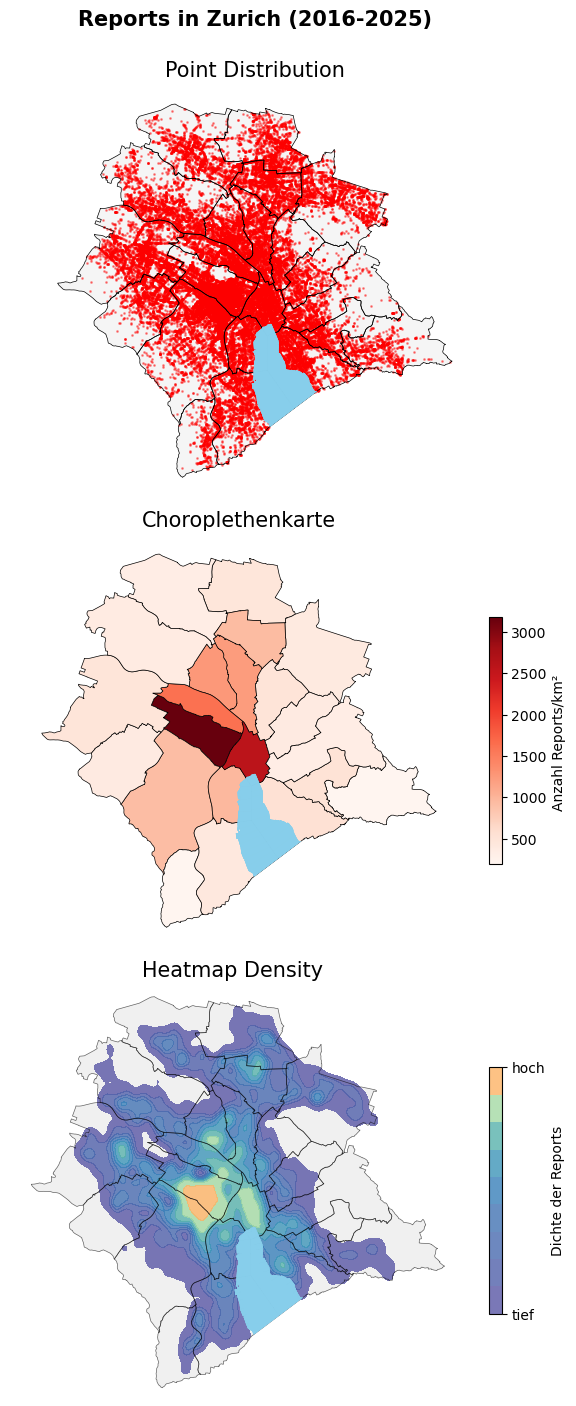

In [4]:
# Plots showing the distribution of reports (2016-2025)
# 1. Point distribution
fig, axs = plt.subplots(3, 1, figsize=(7,14))
fig.suptitle("Reports in Zurich (2016-2025)", fontsize=15, x=0.5, y= 1.001, fontweight='bold')

quartiere_gdf.plot(ax=axs[0], color="whitesmoke", linewidth= 0.5, zorder=1)
reports_gdf.plot(ax=axs[0], color= "red", markersize=1, alpha=0.4, zorder=2)
lakes_gdf.plot(ax=axs[0], color = "skyblue", zorder=4)
quartiere_gdf.boundary.plot(ax=axs[0], color="black", linewidth=0.5, zorder=3)

axs[0].axis("off")
axs[0].set_title("Point Distribution", fontsize=15)

# 2. Choroplethenkarte
# Fläche in km^2 der Quartiere berechnen für Normierung
quartiere_gdf["area_km2"] = quartiere_gdf.geometry.area / 1_000_000

# Spatial Join
reports_quartiere_gdf = gpd.sjoin(reports_gdf, quartiere_gdf, how="inner", predicate="within")
report_counts = reports_quartiere_gdf.groupby("name").size().reset_index(name="count")
quartiere_counts_gdf = quartiere_gdf.merge(report_counts, on="name", how="left")

# Normierung
quartiere_counts_gdf["density"] = quartiere_counts_gdf["count"] / quartiere_counts_gdf["area_km2"]

lakes_gdf.plot(ax=axs[1], color="skyblue",zorder=2)

quartiere_counts_gdf.plot(
    column="density",         
    cmap="Reds",             
    legend=True,              
    legend_kwds={'label': "Anzahl Reports/km² ", 'orientation': "vertical", "shrink": 0.6},
    edgecolor="black",          
    linewidth=0.5,
    ax=axs[1],
    zorder=1
)

axs[1].set_title("Choroplethenkarte", fontsize=15)
axs[1].axis("off")

# 3. Heatmap (Kernel Density Estimate)
quartiere_gdf.plot(ax=axs[2], color="#f0f0f0", edgecolor="none")

sns.kdeplot(
    x=reports_gdf.e, y=reports_gdf.n, 
    ax=axs[2], 
    cmap="Spectral_r", 
    fill=True, 
    thresh=0.05, # ab welcher Dichte die Heatmap angezeigt wird (> 5% des maximalen Wertes)
    alpha=0.8, 
    cbar=True,             
    cbar_kws={"label": "Dichte der Reports", "orientation": "vertical", "shrink": 0.6},
    bw_adjust=0.5  # Beeinflusst, wie glatt die Heatmap ist
)

# Colorbar Skala ändern
cbar = axs[2].collections[-1].colorbar

vmin, vmax = cbar.ax.get_ylim()
cbar.set_ticks([vmin, vmax])

# Die Zahlen durch Text ersetzen
cbar.set_ticklabels(["tief", "hoch"])

lakes_gdf.plot(ax=axs[2], color = "skyblue", zorder= 2)
quartiere_gdf.boundary.plot(ax=axs[2], color="black", linewidth=0.5, alpha=0.6, zorder=1) # only the boundaries

axs[2].axis("off")
axs[2].set_title("Heatmap Density", fontsize=15)

plt.tight_layout() # that they don't overlap
plt.show()


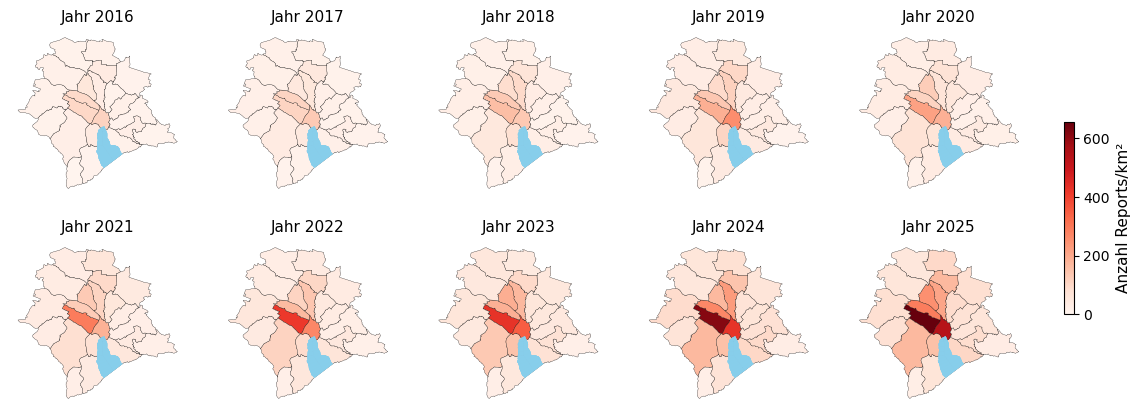

In [6]:
# Das Jahr aus der "date" Spalte extrahieren
reports_gdf["date"] = pd.to_datetime(reports_gdf["date"])
reports_gdf["year"] = reports_gdf["date"].dt.year

# Nach Jahren gruppieren und die Anzahl Reports berechnen
reports_quartiere_gdf = gpd.sjoin(reports_gdf, quartiere_gdf, how="inner", predicate="within") # nochnals gejoint, evt im cleanig hinzufügen
yearly_counts = reports_quartiere_gdf.groupby(["year", "name"]).size().reset_index(name="count")

# Normieren
yearly_density = yearly_counts.merge(quartiere_gdf[["name", "area_km2"]], on="name")
yearly_density["density"] = yearly_density["count"] / yearly_density["area_km2"]
max_yearly_density = yearly_density["density"].max()

# Chorplethenkarten erstellen
fig, axs = plt.subplots(2,5, figsize=(16,5))
axs = axs.flatten()

jahre = range(2016, 2026)

for i, jahr in enumerate(jahre):
    ax = axs[i]
    counts_jahr = yearly_counts[yearly_counts['year'] == jahr]
    show = quartiere_gdf.merge(counts_jahr, on="name", how="left")

    show["density"] = show["count"] / show["area_km2"]
    
    show.plot(column="density", cmap="Reds", vmin=0, vmax=max_yearly_density, 
                  edgecolor="black", linewidth=0.2, ax=ax)
    lakes_gdf.plot(ax=ax, color="skyblue", zorder=2)
    
    ax.set_title(f"Jahr {jahr}", fontsize=11)
    ax.axis("off")

sm = plt.cm.ScalarMappable(cmap="Reds", norm=plt.Normalize(vmin=0, vmax=max_yearly_density))
sm._A = [] 
cbar = fig.colorbar(sm, ax=axs, orientation='vertical', shrink=0.5, pad=0.03)
cbar.set_label("Anzahl Reports/km²", fontsize=11)

plt.show()


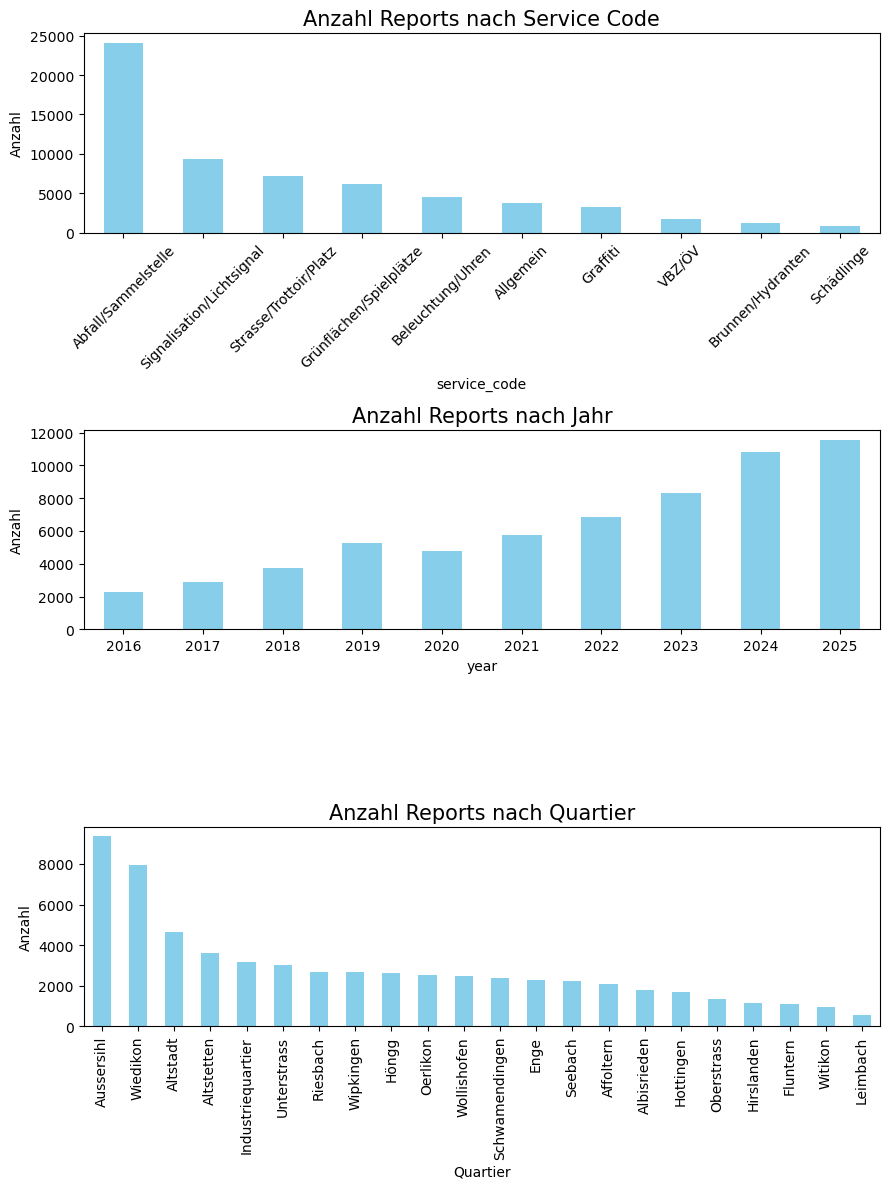

In [7]:
# Historams
fig, axs = plt.subplots(3, 1, figsize=(9,12))

# 1. Service-Codes
reports_gdf["service_code"].value_counts().plot(
    kind='bar', ax=axs[0], color='skyblue'
)
axs[0].set_title("Anzahl Reports nach Service Code", fontsize=15)
axs[0].set_ylabel("Anzahl")
axs[0].tick_params(axis='x', rotation=45)

# 2. Jahr (Chronologisch sortiert!)
reports_gdf["year"].value_counts().sort_index().plot(
    kind='bar', ax=axs[1], color='skyblue'
)
axs[1].set_title("Anzahl Reports nach Jahr", fontsize=15)
axs[1].set_ylabel("Anzahl")
axs[1].tick_params(axis='x', rotation=0) 

# 3. Quartier (Nach Häufigkeit sortiert)
reports_quartiere_gdf["name"].value_counts().plot(
    kind='bar', ax=axs[2], color='skyblue'
)
axs[2].set_title("Anzahl Reports nach Quartier", fontsize=15)
axs[2].set_ylabel("Anzahl")
axs[2].set_xlabel("Quartier")
axs[2].tick_params(axis='x', rotation=90)

# Layout optimieren, damit Titel und Achsen nicht überlappen
plt.tight_layout()
plt.show()

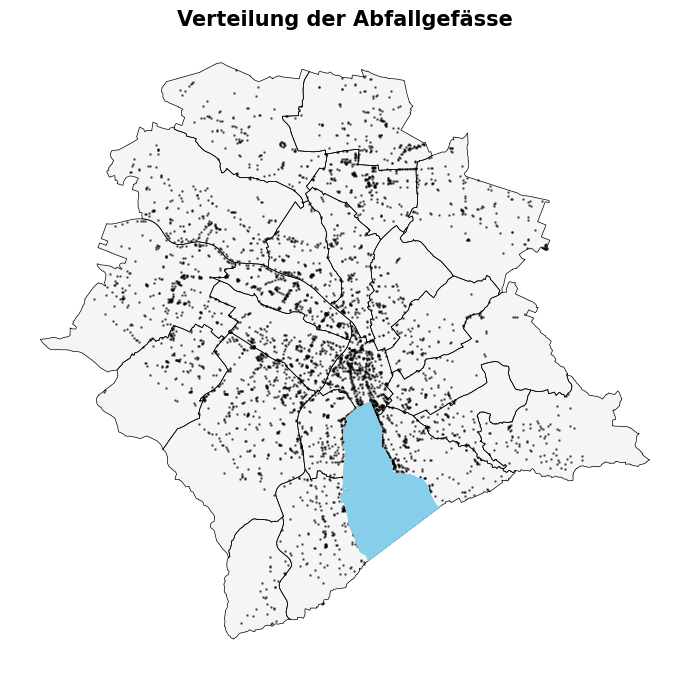

In [ ]:
# Verteilung der Abfallgefässe
abfallgefaesse_file_path = BASE_DIR / "data/raw/abfallgefaesse.gpkg"
abfallgefaesse = gpd.read_file(abfallgefaesse_file_path)
abfallgefaesse = abfallgefaesse.to_crs(epsg=2056)

fig, ax = plt.subplots(figsize=(7, 10))

quartiere_gdf.plot(ax=ax, color="whitesmoke", linewidth=0.5, zorder=1)

abfallgefaesse.plot(
    ax=ax, 
    color="black", 
    markersize=0.8, 
    alpha=0.5, 
    zorder=2, 
    label="Abfallgefässe"
)

lakes_gdf.plot(ax=ax, color="skyblue", zorder=4)

quartiere_gdf.boundary.plot(ax=ax, color="black", linewidth=0.5, zorder=3)

ax.axis("off")
ax.set_title("Verteilung der Abfallgefässe", fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()